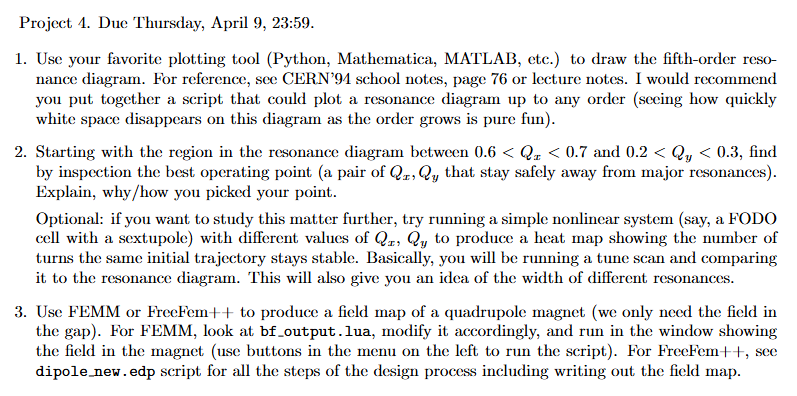

1. Resonance drawing.

If we're going to make it plot arbitrarily many resonances, we should use a script which won't have performance issues with large numbers of lines being drawn. Since matplotlib would run out of artists at large order, we should just draw directly to an image with an array. 

There is a package called `OpenCV` which is made for fast computer vision processing, which happens to include a nice rastering function we can use with numpy to create our own images. That way, I won't have to look up and implement some weird rastering algorithm.

<!-- I'll use numpy since it quickly performs array operations, and draw using pillow. I'll also use seaborn for coloring to better visualize higher order resonances. -->

Jumping straight into programming is probably a bad idea, since our resonance condition isn't exactly a simple $y=f(x)$ right now. We are plotting

$$
m_x Q_x + m_y Q_y = l,
$$
where $Q_x$ and $Q_y$ are the $x$ and $y$ axis, and $l$ is an integer. $m_x$ and $m_y$ are defined by 

$$
|m_x| + |m_y| = O,
$$
where $O$ is the order of the resonance. For our purposes, $Q_x$ and $Q_y$ range from $[0,1]$, so for a given order $O$ we should have $l$ be integers $[-O, O] \in \mathbb{Z}$. With that in mind, we can write this sort of like $y = f(x)$:

$$
\begin{gathered}
    Q_y = {l - m_x Q_x \over m_y},
\\  Q_x = {l - m_y Q_y \over m_x},
\end{gathered}
$$
as long as we handle divide by zero. In fact, for the separate cases $m_x=0$ or $m_y=0$ we have straight horizontal/vertical lines, so those should be computed separately.



In [1]:
# pip install --upgrade pip
# pip install opencv-python
# might throw errors on 3.14 but it still installs just fine

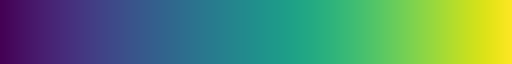

In [2]:
import numpy as np
from cv2 import line
from PIL import Image
from seaborn import color_palette # just for nice colors

color_palette('viridis', as_cmap=True)

In [3]:
def get_ends(order: int):
    l = np.arange(-order, order+1)
    L = l[:, None] # allow broadcasting

    # y = m, x = m
    flat_lines = l/order
    flat_lines = flat_lines[np.logical_and(flat_lines > 0, flat_lines < 1)]

    p0_vlines = np.array([(v,0) for v in flat_lines])
    p0_hlines = np.array([(0,v) for v in flat_lines])
    p1_vlines = np.array([(v,1) for v in flat_lines])
    p1_hlines = np.array([(1,v) for v in flat_lines])

    # pair each +/- mx with each +/- my
    # no zeros m /= order, /= 0
    mx_pos = np.arange(1, order)
    my_pos = order - mx_pos
    mx = np.concatenate([ mx_pos, -mx_pos,  mx_pos, -mx_pos ])
    my = np.concatenate([ my_pos,  my_pos, -my_pos, -my_pos ])
    m_vals = np.stack((mx, my))

    # convert to (x0,y0), (x1,y1) coordinates
    # solve for x,y when y={0,1},x={0,1} and save valid points

    def get_other_cord(x0, m0, m1, l):
        return (l-m0*x0)/m1

    vget_cord = np.vectorize(get_other_cord, excluded=['x0'])
    x_down = vget_cord(x0=0, m0=my, m1=mx, l=L) # y = 0
    x_up   = vget_cord(x0=1, m0=my, m1=mx, l=L) # y = 1
    y_left = vget_cord(x0=0, m0=mx, m1=my, l=L) # x = 0
    y_right= vget_cord(x0=1, m0=mx, m1=my, l=L) # x = 1

    # convert to tuple-like
    # shape: [m,l,x/y]
    p_left  = np.stack([np.zeros_like(y_left), y_left ], axis=-1)# (0, y)
    p_right = np.stack([np.ones_like(y_right), y_right], axis=-1)# (1, y)
    p_down  = np.stack([x_down, np.zeros_like(x_down) ], axis=-1)# (x, 0)
    p_up    = np.stack([x_up,   np.ones_like(x_up)    ], axis=-1)# (x, 1)

    # shape: [4,m,l,x/y]
    # now all points are matched up to their m/l terms
    all_points = np.stack([p_left, p_right, p_down, p_up])

    # mask with open intervals to avoid double counting corners
    # true if point lies on square edge
    m_left  = (y_left >= 0) & (y_left < 1)
    m_right = (y_right > 0) & (y_right <= 1)
    m_down  = (x_down > 0)  & (x_down <= 1)
    m_up    = (x_up >= 0)   & (x_up < 1)

    # now check if there are exactly 2 points crossing the border
    # make mask even more stringent
    mask  = np.stack([m_left, m_right, m_down, m_up]) # [4,m,l]
    crossings = np.sum(mask, axis=0) #[m, l]

    valid_points = all_points[:, crossings == 2, :].transpose(1,0,2) # [n_valid, 4, x/y]
    valid_mask = mask[:, crossings == 2].T # [n_valid, 4], lists the sides the line intersects
    valid_lines = valid_points[valid_mask] # alternating points for each line
    

    # (x0, y0), (x1, y1)
    p0 = valid_lines[0::2]
    p1 = valid_lines[1::2]
    return np.concat((p0, p0_vlines, p0_hlines)), np.concat((p1, p1_vlines, p1_hlines))

def draw_lines(p0_list, p1_list, color, img = None, resolution = 2000, thickness=1):
    color = tuple(int(c) for c in color)
    if img is None:
        img = np.ones((resolution, resolution, 3), dtype=np.uint8)*255
    for p0, p1 in zip(p0_list, p1_list):
        p0i = np.clip(np.round(p0 * (resolution - 1)).astype(int), 0, resolution-1)
        p1i = np.clip(np.round(p1 * (resolution - 1)).astype(int), 0, resolution-1)
        line(img, p0i, p1i, color=color, thickness=1)
    return img

Oh my gosh that was so much work.

Anyways, let's see what the resonance plot up to 5th order turns out like. 

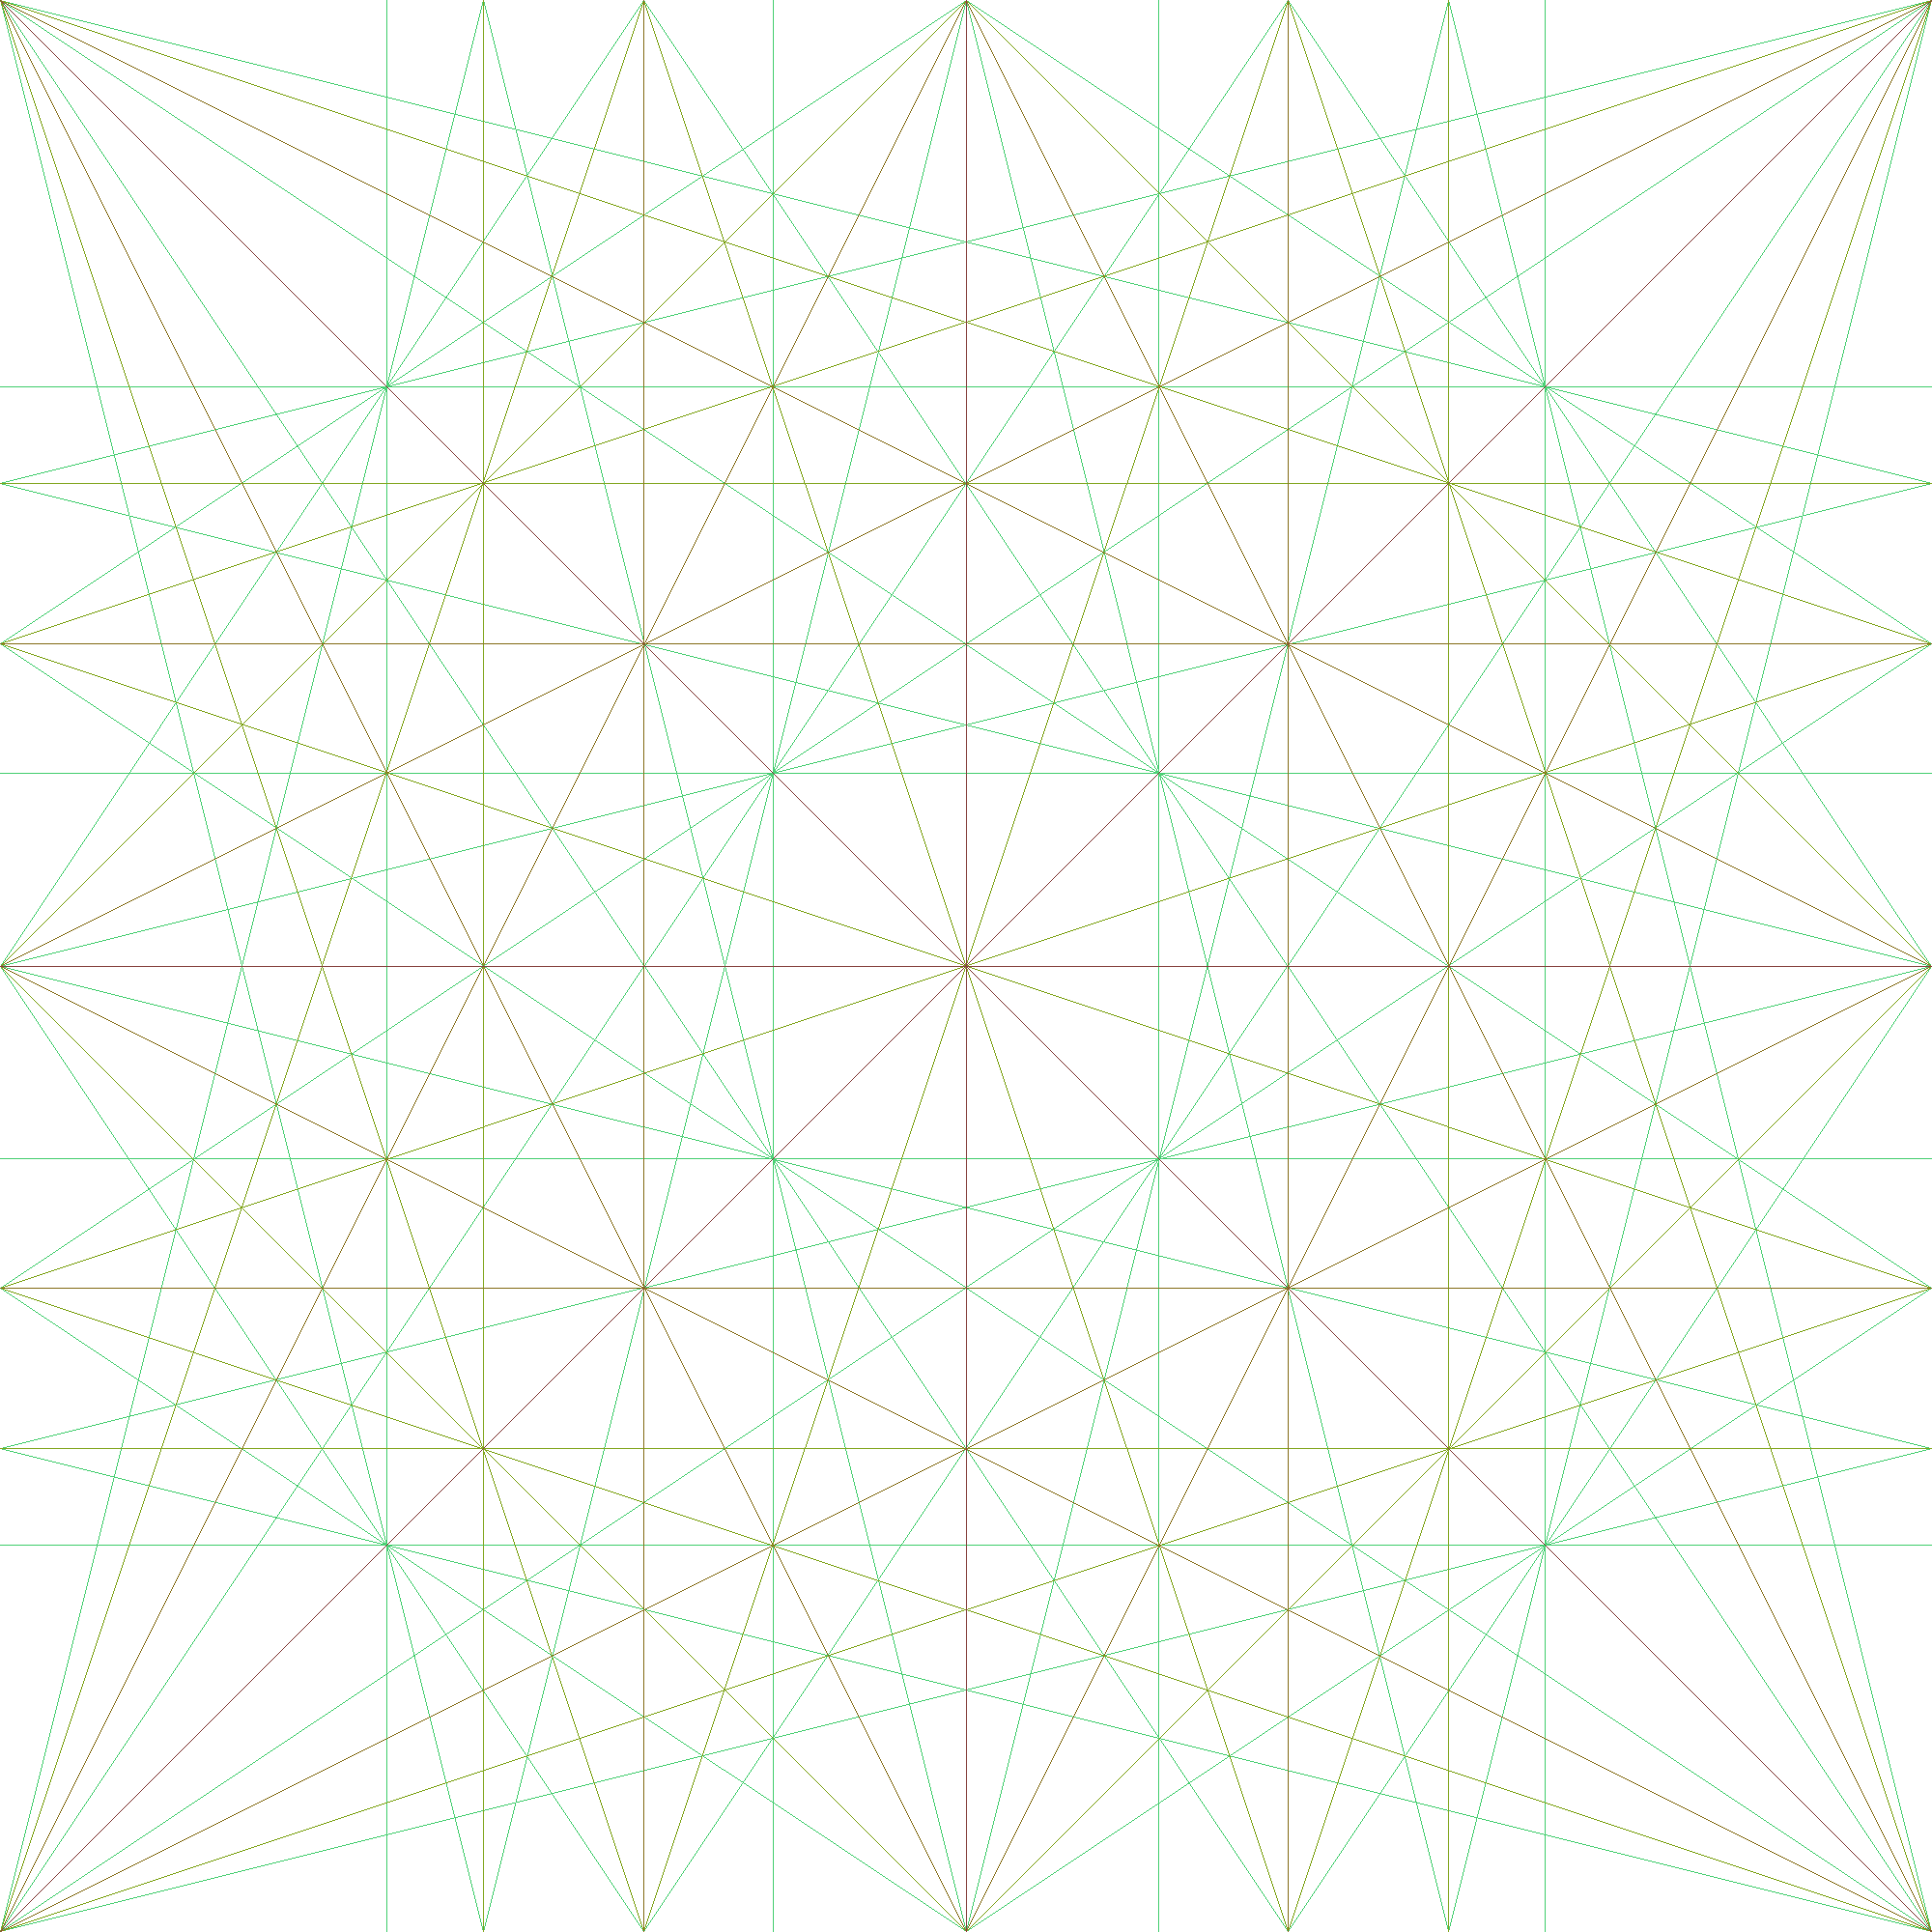

In [4]:
max_order = 5
order_colors = (np.array(color_palette('viridis', n_colors=max_order-1))*255).astype(int)[:,(2,1,0)]

# plot in reverse order so lower orders are drawn on top
# min order = 2
img = None

for order in range(max_order, 1, -1):
    color = order_colors[order-2]
    p0, p1 = get_ends(order)
    img = draw_lines(p0, p1, color, img=img)

Image.fromarray(img)



That is gorgeous! But, check this out:

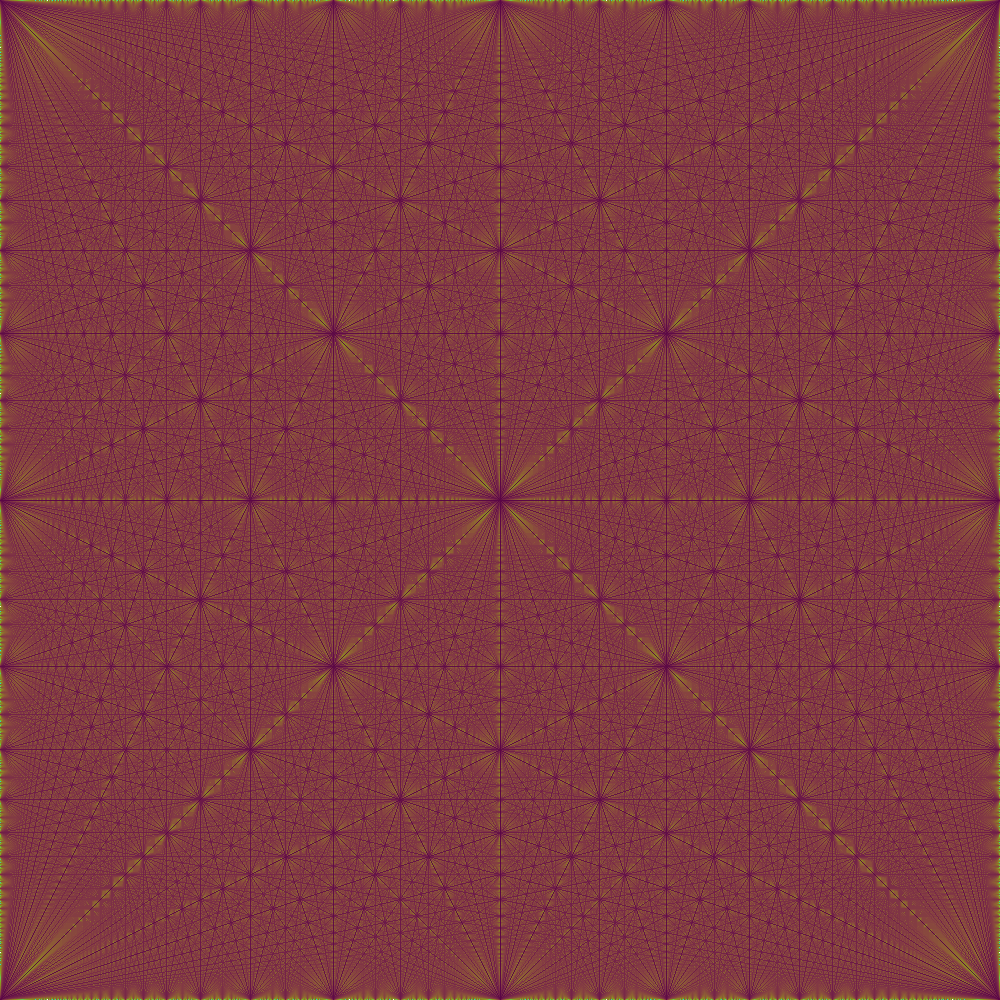

In [5]:
from IPython.display import display, clear_output

colors = [
    'viridis_r',
    'cubehelix',
    'cubehelix_r',
    'icefire_r',
    'nipy_spectral',
    'prism', # strobe warning
    'tab10',
    'gist_rainbow',
    'gist_ncar',
    'bone_r',
]

max_order = 60
order_colors = (np.array(color_palette(colors[0], n_colors=max_order-1))*255).astype(int)[:,(2,1,0)]

img = None
for i, order in enumerate(range(max_order, 1, -1)):
    color = order_colors[i]
    p0, p1 = get_ends(order)
    img = draw_lines(p0, p1, color, img=img, resolution = 1000) 

    print(i)
    clear_output(wait=True)
    display(Image.fromarray(img))


clear_output(wait=True)
display(Image.fromarray(img))



Or, a high fidelity render: Use mspaint or another simple png viewer and just keep scrolling.

In [6]:
if True:
    'this takes a while to run'
else:
    max_order = 100
    order_colors = (np.array(color_palette('viridis_r', n_colors=max_order-1))*255).astype(int)[:,(2,1,0)]
    
    img = None
    for i, order in enumerate(range(max_order, 1, -1)): # 3 minutes
        if i % 10 == 0: # 
            print(i)
        color = order_colors[i]
        p0, p1 = get_ends(order)
        img = draw_lines(p0, p1, color, img=img, resolution = 20000) 
    
    
    Image.fromarray(img).save('high_res.png') 

Higer order modes are almost completely clouded out after a certain point. Using a grayscale image we can get a sense of what orders dominate the resonance map.

In [7]:
max_order = 100

img = None
for i, order in enumerate(range(max_order, 1, -1)): 
    # if i % 10 == 0: # 
    #     print(i)
    color = (i, i, i)
    p0, p1 = get_ends(order)
    img = draw_lines(p0, p1, color, img=img, resolution = 5000) 

80.24530304 81.0 0


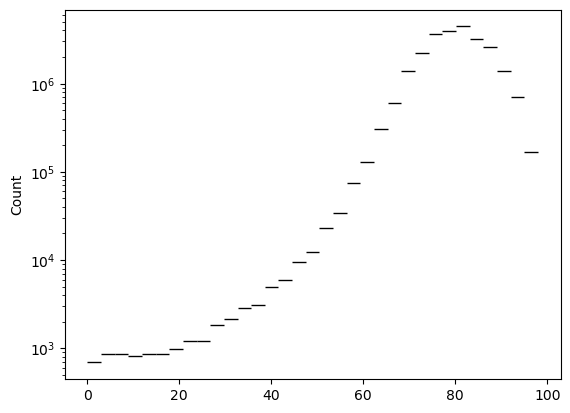

In [8]:
import seaborn as sns

pixel_vals = img[:,:,0].ravel()
sns.histplot(data=pixel_vals[pixel_vals != 255], log_scale=(False,True), binwidth=3)

print(
    pixel_vals.mean(), 
    np.median(pixel_vals),
    pixel_vals.min()
)

Looks like high-orders are actually dominate, despite being drawn on before the lower orders. I bet this curve depends heavily on resolution (I've excluded whitespace).